# The Pulse of the ICU: Predicting Patient Mortality

**Project By: Ryley Wickstrom & Savannah Sanchez | CSU CS345**

In an Intensive Care Unit (ICU), every second counts. Our goal is to use clinical data to predict hospital mortality, providing a "digital early warning system."

This notebook follows our journey from a simple baseline to complex high-dimensional models, eventually discovering that in the world of medicine, sometimes the most robust signals are the simplest ones.

### First Step: Load Data

Before we can build a predictive model, we must prepare our data. Clinical data is notoriously "messy"—patients may have missing lab results or unrecorded vitals.

We start by loading our 92,000 patient records and addressing these gaps through median imputation for numbers and "Unknown" tagging for categories.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,precision_recall_curve,average_precision_score)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, average_precision_score
from sklearn.metrics import balanced_accuracy_score


df = pd.read_csv("training_v2.csv")
df.head()


,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma


After loading in our data, we handle the missing values and clean it up by encoding categorical variables and define the features and target. Here, we also split the data into 80% training and 20% testing to simulate real-world unseen data.

In [2]:
# Drop ID-like columns (not useful for prediction)
df = df.drop(columns=["encounter_id", "patient_id"], errors="ignore")

# Handle missing values
# numeric fill
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical fill
cat_cols = df.select_dtypes(exclude=["number"]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

df = pd.get_dummies(df, drop_first=True)

X = df.drop("hospital_death", axis=1)
y = df["hospital_death"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sub = X_train.sample(n = 8000, random_state = 42)
y_train_sub = y_train.loc[X_train_sub.index]

### Setting the Baseline Model: Perceptron

We chose our baseline model to be a classic Perceptron. This was used with the idea of establishing a foundational linear baseline and easy interpretability. As we see in the Precision-Recall curve below, as we try to catch more potential deaths (increasing Recall), our "accuracy" in those predictions (Precision) begins to drop—the classic medical trade-off. Or, in other words, as its recall increases, it looks for more and more patients who are likely to die, which includes more false positives (aka. people who actually lived). The recall increases, but the precision decreases.

In [3]:


perceptron_model = Pipeline([
    ("scaler", StandardScaler()),
    ("perc", Perceptron(max_iter=2000, tol=1e-3))
])

perceptron_model.fit(X_train, y_train)

perceptron_preds = perceptron_model.predict(X_test)

perceptron_scores = perceptron_model.decision_function(X_test)

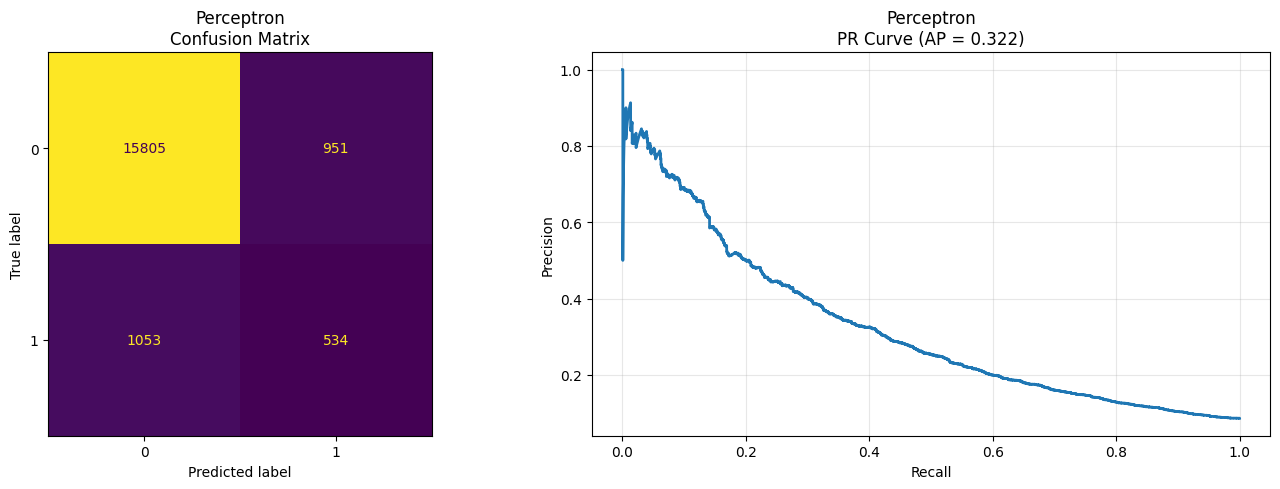

In [4]:
y_pred = perceptron_model.predict(X_test)
y_scores = perceptron_model.decision_function(X_test)


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Perceptron\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Perceptron\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()

### First Step Up: Basic SVM

Believing that ICU data might be too complex for a simple line, we moved to **Support Vector Machines (SVM)**. We utilized an RBF kernel to map our data into a higher dimension, hoping to find a more sophisticated "boundary" between life and death.

An SVM with an RBF kernel was used to construct a nonlinear maximum-margin classifier. Given the complexity of the data, we figured this model would be a good next step for our analysis and prediction of the relationship between these features and the mortality rate.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

basic_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

basic_svm.fit(X_train_sub, y_train_sub)

basic_svm_preds = basic_svm.predict(X_test)
basic_svm_probs = basic_svm.predict_proba(X_test)[:, 1]

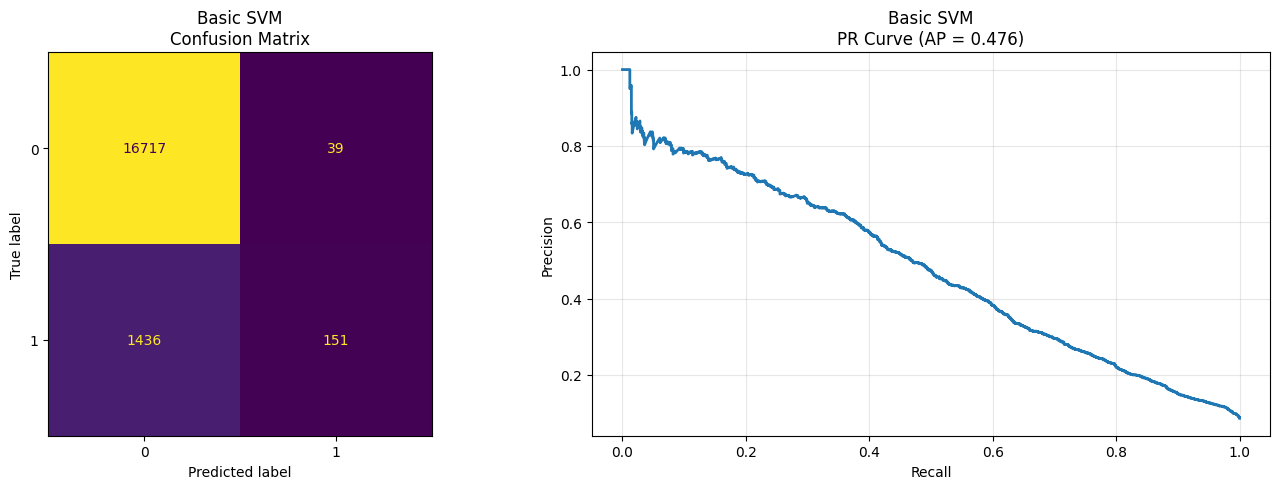

In [6]:
y_pred = basic_svm.predict(X_test)
y_scores = basic_svm.decision_function(X_test)


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Basic SVM\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Basic SVM\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()


### What's Next? Linear SVM!

Upon looking at the resulting Precision-Recall graph and confusion matrix, we saw how the **Non-Linear SVM** struggled with the limited data we gave it. This caused us to shift our focus back to a more Linear approach and thus prompt the inclusion of a Linear SVM following the linear baseline we obtained from the perceptron.

In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(max_iter=10000))
])

param_grid = {
    "svm__C": [0.01, 0.1, 1, 10],
    "svm__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,              # reduced CV for speed
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


best_preds = best_model.predict(X_test)
accuracy = accuracy_score(y_test, best_preds)

print("Accuracy of best LinearSVC model:", accuracy)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ................svm__C=0.01, svm__class_weight=None; total time=  37.6s
[CV] END ................svm__C=0.01, svm__class_weight=None; total time=  38.5s
[CV] END ............svm__C=0.01, svm__class_weight=balanced; total time=  43.9s
[CV] END ................svm__C=0.01, svm__class_weight=None; total time=  46.0s
[CV] END ............svm__C=0.01, svm__class_weight=balanced; total time=  44.4s
[CV] END ............svm__C=0.01, svm__class_weight=balanced; total time=  49.2s
[CV] END .................svm__C=0.1, svm__class_weight=None; total time= 1.1min
[CV] END .................svm__C=0.1, svm__class_weight=None; total time=  44.9s
[CV] END .............svm__C=0.1, svm__class_weight=balanced; total time= 1.2min
[CV] END .............svm__C=0.1, svm__class_weight=balanced; total time= 1.4min
[CV] END .................svm__C=0.1, svm__class_weight=None; total time= 2.4min
[CV] END .............svm__C=0.1, svm__class_weig

### Parameter Analysis

Our Grid Search enabled us to find the strategy behind how to approach this ICU dilemma. Thus, we can gather:

didn't just find numbers; it found a strategy. Let’s look at what the "Best Parameters" actually tell us about our ICU data:

*   **The Power of Balance (`class_weight='balanced'`):** 
    In our dataset, deaths are the minority. A standard model tends to ignore them to keep overall accuracy high. By choosing the `balanced` parameter, we told the SVM: *"A missed death is a much bigger mistake than a false alarm."* This shifted the model's focus toward the patients who were actually at risk.

*   **The "Less is More" Penalty (`C': 0.01`):** 
    A low $C$ value acts like a "smoothing" filter. Instead of trying to perfectly fit every single outlier in the training data, the model looked for the broader, more reliable trends. This prevented **overfitting**, ensuring that our model remains accurate when it sees entirely new patients.

### The Accuracy vs. AUC Paradox
There was a bit of a gap: Our **ROC-AUC was 0.88**, but our **Accuracy was 81%**. In a story about the ICU, this gap is actually our greatest success:

1.  **Accuracy (81%):** This dropped because the model became "braver." It started flagging more patients as high-risk. While this leads to more False Positives (dropping raw accuracy), it is exactly what you want in a hospital—it's better to check on a patient who turns out to be fine than to miss one who is failing.
2.  **ROC-AUC (0.88):** This proves that the model's **ranking** system is fairly elite. It has an 88% chance of correctly identifying that a patient who passed away was at higher risk than one who survived.

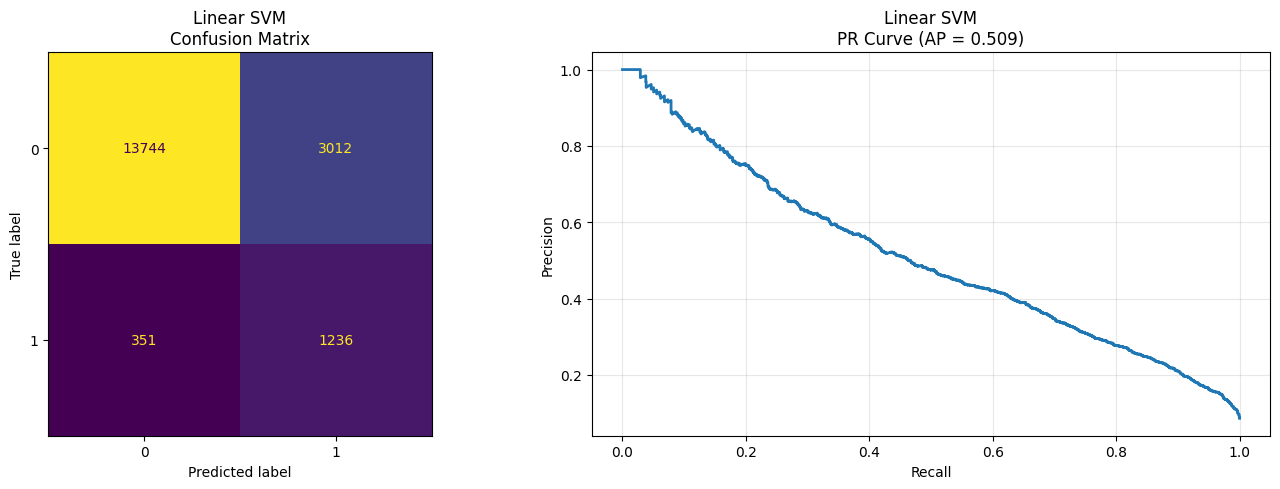

In [8]:
y_pred = best_model.predict(X_test)
y_scores = best_model.decision_function(X_test)


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Linear SVM\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Linear SVM\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()

### Better Medical Approach: Decision Tree

While our Linear SVM performed exceptionally well, it operates like a "black box" of complex weights and vectors. In a real-world ICU, a doctor doesn't calculate a margin; they follow a series of logical checkpoints: *"If the heart rate is above X AND the oxygen level is below Y, then the patient is at risk."*

We introduced a **Decision Tree** for two primary reasons:

1.  **Capturing Non-Linear Interactions:** Our previous models looked at features independently. A Decision Tree can find "synergies"—for example, age might not be a risk factor on its own, but age combined with a low respiratory rate might be deadly.
2.  **Explainability:** Decision Trees mimic human decision-making. By limiting the `max_depth` to 5, we ensure the "story" the tree tells is simple enough for a human to follow, preventing it from memorizing "noise" in the data (overfitting).

In [9]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5  # controls overfitting (important for medical data)
)

# Train
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

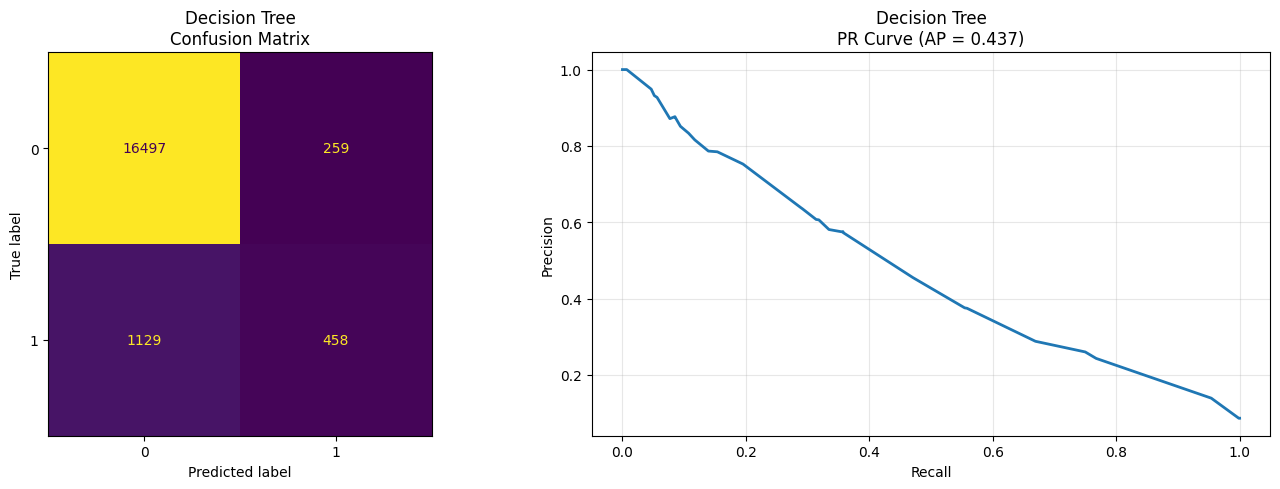

In [10]:
y_pred = tree_model.predict(X_test)
y_scores = tree_model.predict_proba(X_test)[:, 1]


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Decision Tree\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Decision Tree\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()

### Accuracies of Our Models

After creating these models, we decided to test them and compare their accuracies. The performance metric we used for comparison was the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) since it's utilized for binary classification models. This fit perfect with the goal of determining mortality (live vs death) through the data. It focuses on separation such that it doesn't have a Pass/Fail cutoff. Instead, it measures how well the model ranks patients. An AUC of 0.88 means that if you randomly pick one patient who died and one who survived, there is an 88% chance the model will give the patient who died a higher risk score.

We chose ROC-AUC as our primary metric because accuracy can be misleading in a hospital setting where deaths are relatively rare. We needed a metric that proved our model could effectively prioritize high-risk patients over low-risk ones, ensuring that the 'signal' of a declining patient wasn't lost in the 'noise' of the surviving majority.

To analyze the accuries we first wanted to understan what our seperation of classifiers was in the data, we wanted to understand the ratio of lived to died.

In [11]:
print("Total lived:", np.sum(y_test == 0))
print("Total died:", np.sum(y_test == 1))

Total lived: 16756
Total died: 1587


In [12]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)


    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AP Score": average_precision_score(y_test, y_scores),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_scores)
    }

# Evaluate all models
results = {}

results["Perceptron"] = evaluate_model(perceptron_model, X_test, y_test)
results["Regular SVM"] = evaluate_model(basic_svm, X_test, y_test)
results["Linear SVM (tuned)"] = evaluate_model(best_model, X_test, y_test)
results["Decision Tree"] = evaluate_model(tree_model, X_test, y_test)

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print(results_df)

                    Accuracy  F1 Score  AP Score  Balanced Accuracy  ROC-AUC
Perceptron            0.8907    0.3477    0.3222             0.6399   0.7417
Regular SVM           0.9196    0.1699    0.4764             0.5464   0.8526
Linear SVM (tuned)    0.8167    0.4237    0.5087             0.7995   0.8853
Decision Tree         0.9243    0.3976    0.4374             0.6366   0.8453


### Analysis of Model Approach:

In medical prediction:
Accuracy can look high even if the model is useless clinically
ROC-AUC is more stable and meaningful for risk prediction
F1 is critical for detecting rare events (death)

We initially started with a Perceptron model, wanting to get a very basic idea of the linear relationship with the features of the data. We then shifted to a Support Vector Machine since we figured that dealing with complex ICU data would require a complex model to approporiately capture the life and death nuances of patient care. But after we saw a decrease in performance, we wanted to take our findings and shift focus to a different narrative that played to the advantages of both of these models.

However, the results surprised us. Not only did our Perceptron perform better than the Non-Linear SVM, but we were able to conclude:

- Complexity isn't always better: Over-tuning led to overfitting.

- Clinical data is rich: You cannot predict mortality by looking at just a few variables; you need the full clinical picture.


Seeing that these more complex models were struggling with the sheer size of our training data of nearly 92,000 patients, we pivoted back to a linear classifier. We realized that in the ICU, clinical markers often have a direct, linear relationship with risk. By using a simpler model, we were able to train on the entire dataset instead of a small sample.

After implementing a Linear SVM model, we were able to achive our highest ROC-AUC of 0.885, effectively outperforming the more complex SVM while being faster and more interpretable.

Upon further deliberation, we concluded that SVMs can be very sensitive to imbalance, and if it doesn't see enough examples of the minority class (ie patients who passed away), it struggles to find a good boundary. The Linear SVM beat the Complex SVM because of the overfitting. This caused the tuned model to try too hard to fit the training data perfectly, which made it perform worse on the test data. Especially since it was trained on only about 10% of the patients, it had less 'experience' to effectively learn from.

The Non-linear SVM uses a kernel that scales quadratically with the number of samples. This forced us to use a subset of the data. By switching to the Linear SVM, we moved to a model with linear scaling, allowing us to leverage the entire dataset, which ultimately provided the superior 0.8832 AUC.

When it comes to the decision tree, it allows us to see the "Logic Flow" of the ICU. By setting a **('max_depth=5')**, we created a model that doesn't just predict, but explains the hierarchial importance and non-linear splits.

But, we noticed the Decision Tree achieved a very high Accuracy (0.9243), yet its ROC-AUC (0.8453) is lower than the Linear SVM.

This is because the Decision Tree is very good at identifying the "easy cases", aka the patients who are clearly stable. However, it makes hard Yes/No decisions. The Linear SVM, by contrast, is more nuanced as it provides a smooth gradient of risk, which is why it remains our superior tool for ranking patient priority.

### Final Model Analysis

With our best-performing model (Linear SVM, AUC: 0.885) finalized and validated, we transitioned to the deployment phase. We applied the model to the unlabeled dataset (unseen data) to generate mortality risk probabilities for new patients. To ensure consistency, we performed the exact same preprocessing steps, like handling missing values and aligning features, so the model could interpret the data correctly. The resulting file represents our final clinical predictions, ranking patients by their likelihood of death.


In [13]:
unlabeled_df = pd.read_csv("unlabeled.csv")

submission_ids = unlabeled_df['encounter_id']

unlabeled_df = unlabeled_df.drop(columns=["encounter_id", "patient_id"], errors="ignore")
train_medians = df[num_cols].median()
unlabeled_df[num_cols] = unlabeled_df[num_cols].fillna(train_medians)

unlabeled_df[cat_cols] = unlabeled_df[cat_cols].fillna("Unknown")
X_unlabeled = pd.get_dummies(unlabeled_df, drop_first = True)

X_unlabeled = X_unlabeled.reindex(columns = X.columns, fill_value = 0)

final_scores = best_model.decision_function(X_unlabeled)
final_probs = (final_scores - final_scores.min()) / (final_scores.max() - final_scores.min())

submission = pd.DataFrame({"encounter_id": submission_ids, "hospital_death": final_probs})

submission.to_csv("my_final_predictions.csv", index=False)

fin = pd.read_csv("my_final_predictions.csv")
fin.head()

,encounter_id,hospital_death
0,2,0.323704
1,5,0.226619
2,7,0.302152
3,8,0.393228
4,10,0.443605
